# 6. When a director takes the workbook in the room, what can they break, and which checks catch it before anyone reads a wrong number?

**Week 2, Friday. Chapter 6 of 6.** Chapters 1 to 4 built the three deliverables: the tree for both
quarters tied to the warehouse, the protect list of fifty from Rs 25,840 down to Rs 8,580 with a lookup
that says when an id is missing, and the front-page card with its period, comparison and base. Chapter 5
set the rule: the warehouse owns the number, pandas the iteration, the workbook the last mile, with a
drift check on every refresh. The chief of staff's last condition is the hardest: "If a director changes
an assumption in the room, the sheet must recalculate in front of them."

> **The client asks.** "Monday's growth review deck needs three things I can open on my laptop
> without a login: the revenue tree by segment for both quarters, the top-fifty protect list with a
> lookup so I can find any member by id, and one number on the front page with its trend. Nothing
> that needs Python. If a director changes an assumption in the room, the sheet must recalculate in
> front of them."
>
> Meera's chief of staff, Kalpa Retail

**Who needs the answer.** The chief of staff hands the laptop across the table mid-meeting; the
directors will filter, sort, type and ask what-ifs; the head of Retail-Plus sizes each city's retention
budget from the list. A total that keeps counting rows a filter has hidden sizes a city's budget on the
whole list, and a number typed over a formula becomes a figure nobody can trace.

**The questions on the way.**
1. What will a director do to the workbook?
2. How could the team protect it?
3. What does the list's total say when a director filters it to one city?
4. What do SUBTOTAL(109) and SUBTOTAL(103) say?
5. Where does a director's assumption go, so the sheet recalculates honestly?
6. Which checks does the Checks tab run, and what does its release hold?

**The metric at stake.** The protect list's total by city, which sizes each city's retention budget, and
the release sentence that says what ships on Monday.

**Who else faces it.** In September 2008 Barclays bought parts of the bankrupt Lehman Brothers. A law
firm reformatting a spreadsheet of the contracts into a PDF for the court's website exposed rows that
had been hidden, and "contracts that had been marked as "hidden" in the spreadsheet when it was
received by the law firm were added to the purchase offer during the reformatting process"; Barclays
then asked the court to exclude 179 contracts it said were included by mistake (Computerworld, 14
October 2008, checked 30 September 2026). Rows a person could not see still counted.

**Setup.** The cell loads the customer table and the raw export from `../data/`, rebuilds chapter 3's
protect list (the 106 Retail-Plus members sorted by revenue, the top fifty kept), and defines
`warehouse()`, which the Checks tab uses to tie the sheet to the warehouse.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv
import pandas as pd

DATA = kit.data_dir()
SEGMENTS = ["Business", "Retail-Core", "Retail-Plus", "Student"]


def crore(n):
    return f"Rs {n / 1e7:.2f} crore"


def lakh(n):
    return f"Rs {n / 1e5:.2f} lakh"


def money(n):
    """Rupees the way Kalpa's finance team reads them: crore, lakh, or rupees in full."""
    sign, a = ("-" if n < 0 else ""), abs(n)
    return sign + (crore(a) if a >= 1e7 else lakh(a) if a >= 1e5 else kit.rupees(round(a)))


def change(before, after):
    """The change from before to after, measured on before, in percent."""
    return (after - before) / before * 100

table = pd.read_csv(DATA / "C2_W02_D05_customer_table_STUDENT.csv")

raw = pd.read_csv(DATA / "C2_W02_D05_raw_export_STUDENT.csv", keep_default_na=False)
raw["quarter"] = raw["order_date"].str[5:7].astype(int).map(lambda m: "Q1" if m <= 6 else "Q2")


def warehouse(query):
    """Ask the Kalpa warehouse itself, the source of truth every sheet ties back to."""
    return [{k: (int(v) if hasattr(v, "as_integer_ratio") and not isinstance(v, float) else v)
             for k, v in row.items()} for row in kit.sql(query)]

plus = (table[table["segment"] == "Retail-Plus"]
        .sort_values(["revenue", "customer_id"], ascending=[False, True]).reset_index(drop=True))
plus["rank"] = plus.index + 1
protect = plus.head(50).copy()                       # the protect list, rank 1 to 50

print(len(protect), "members on the list,", kit.rupees(int(protect["revenue"].sum())), "together")

50 members on the list, Rs 7,14,890 together


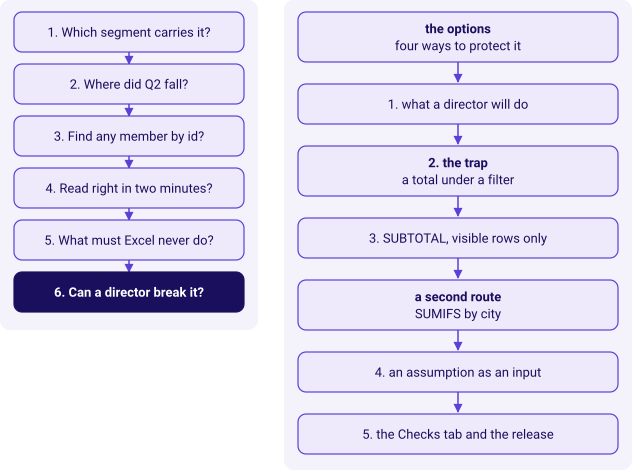

In [2]:
kit.side_by_side(
    kit.ladder(['Which segment carries it?', 'Where did Q2 fall?', 'Find any member by id?', 'Read right in two minutes?', 'What must Excel never do?', 'Can a director break it?'], lit=5, show=False),
    kit.vflow(['the options\nfour ways to protect it', '1. what a director will do', '2. the trap\na total under a filter', '3. SUBTOTAL, visible rows only', 'a second route\nSUMIFS by city', '4. an assumption as an input', '5. the Checks tab and the release'], show=False),
)

## How could the team protect the workbook, and what does each way cost?

| Option | What the director can still do | What a mistake looks like |
|---|---|---|
| a) Protect every cell | Read it; filter and sort only if the protection allows them | Nothing can go wrong, and no what-if can be asked |
| b) Send a PDF | Read it | Nothing can go wrong, and nothing recalculates |
| c) Yellow input cells, every other cell a formula, and a Checks tab | Filter, sort and change any yellow input | A red line on the Checks tab, and a release that holds |
| d) A copy for each director | Anything | Copies that disagree by the end of the meeting, with no way to tell which is right |

option,"director actions it allows, of 5",a wrong number is caught by
a) protect every cell,2,nothing to catch
b) PDF,0,nothing to catch
c) inputs and a Checks tab,5,each check turns red
d) a copy each,5,nothing: copies drift apart


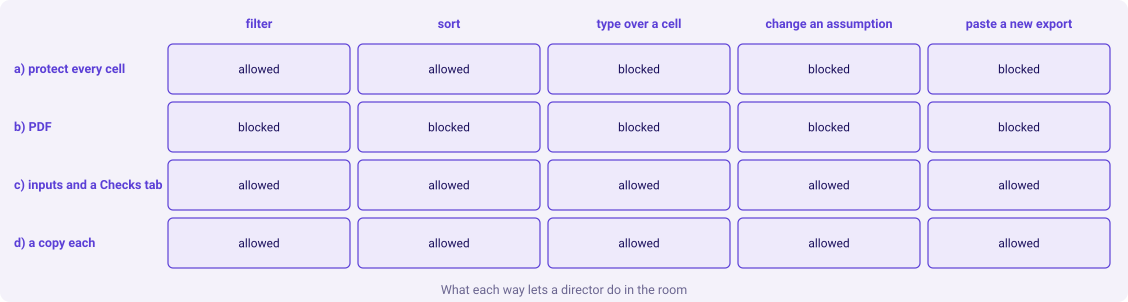

In [3]:
actions = ["filter", "sort", "type over a cell", "change an assumption", "paste a new export"]
allowed = {"a) protect every cell": [1, 1, 0, 0, 0], "b) PDF": [0, 0, 0, 0, 0],
           "c) inputs and a Checks tab": [1, 1, 1, 1, 1], "d) a copy each": [1, 1, 1, 1, 1]}
caught = {"a) protect every cell": "nothing to catch", "b) PDF": "nothing to catch",
          "c) inputs and a Checks tab": "each check turns red", "d) a copy each": "nothing: copies drift apart"}
kit.table(["option", "director actions it allows, of 5", "a wrong number is caught by"],
          [(k, sum(v), caught[k]) for k, v in allowed.items()], caption="The four ways, sized on the five things a director does")
kit.matrix(list(allowed), actions, [["allowed" if a else "blocked" for a in v] for v in allowed.values()],
           title="What each way lets a director do in the room")

**The best-fit call: c.** It is the only way that lets a director do all five things and still turns a
wrong number red before it is read. Protecting every cell (a) or sending a PDF (b) fails the brief, since
nothing recalculates; a copy each (d) ends the meeting with several versions of the truth. **The fact
that would change it:** a board pack nobody is meant to change goes as a PDF.

## 1. What will a director do to the workbook?

**Predict before you run.** Which of these changes what a number on the sheet means without any error
appearing? a) filtering the list; b) typing a figure over a formula; c) changing a yellow input; d) a
and b, and neither shows an error.

What a director does,What happens to the sheet,Error shown?
filter the list to a city,the rows on screen change; a SUM below them does not,silent
sort one column on its own,the rows' values separate from their ids,silent
type a figure over a formula,the cell stops following its source,silent
change a yellow input,every formula reading it recalculates,honest
paste in a new export,"the formulas read the new rows, if their ranges reach them",checked by the drift check


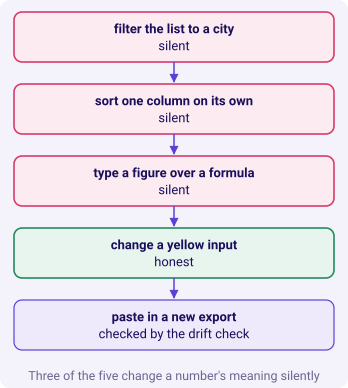

In [4]:
effects = [("filter the list to a city", "the rows on screen change; a SUM below them does not", "silent"),
           ("sort one column on its own", "the rows' values separate from their ids", "silent"),
           ("type a figure over a formula", "the cell stops following its source", "silent"),
           ("change a yellow input", "every formula reading it recalculates", "honest"),
           ("paste in a new export", "the formulas read the new rows, if their ranges reach them", "checked by the drift check")]
kit.table(["What a director does", "What happens to the sheet", "Error shown?"], effects)
kit.vflow([e[0] + "\n" + e[2] for e in effects], kinds=["bad", "bad", "bad", "good", "plain"],
          title="Three of the five change a number's meaning silently")

**What happened.** The answer is d. A filter and a typed-over cell both change what a number means,
and neither shows an error; a one-column sort is the third silent one. A yellow input is the honest way to
change a number, because every formula that reads it recalculates in front of the room. The next two
questions take the filter, and question 5 takes the input.

## 2. What does the list's total say when a director filters it to one city?

The protect list has a total at its foot, `=SUM(E2:E51)`. The head of Retail-Plus asks to see the
Mumbai members, and a director filters the city column to Mumbai.

**Predict before you run.** With eleven Mumbai members on screen, the foot reads: a) Rs 1,56,790; b)
Rs 7,14,890; c) 11; d) #VALUE!.

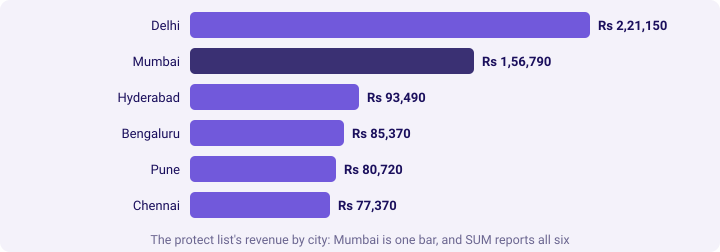

In [5]:
visible = protect["city"] == "Mumbai"                 # the rows the filter leaves on screen
foot_sum = int(protect["revenue"].sum())              # =SUM(E2:E51) adds every row, hidden or not
on_screen = int(protect.loc[visible, "revenue"].sum())
kit.stats([(kit.rupees(foot_sum), "the foot, SUM", "all fifty rows"),
           (kit.rupees(on_screen), "what the eleven on screen spent", "Mumbai's list"),
           (f"{foot_sum / on_screen:.1f} times", "the overstatement", "read as Mumbai's list")])
by_city = protect.groupby("city")["revenue"].sum().sort_values(ascending=False)
kit.bars([(c, int(v)) for c, v in by_city.items()], fmt=kit.rupees, lit=(list(by_city.index).index("Mumbai"),),
         title="The protect list's revenue by city: Mumbai is one bar, and SUM reports all six")
kit.check("SUM under the filter still adds all fifty rows", foot_sum == int(protect["revenue"].sum()))
kit.check("the eleven on screen are a small part of it", on_screen < foot_sum / 4, kit.rupees(on_screen))

**What happened: the plausible wrong answer.** The answer is b. The foot still reads Rs 7,14,890, the
whole list, while the eleven Mumbai members on screen spent Rs 1,56,790. **Why it is wrong:** the Mumbai
store head is told the members on their list spent Rs 7.15 lakh, and a retention budget sized on that is
4.6 times too big. SUM adds every row in its range, hidden or not. **The check that catches it:** count
the rows on screen beside the rows the total adds; if the two differ, the total is adding rows nobody can
see.

## 3. What do SUBTOTAL(109) and SUBTOTAL(103) say?

`=SUBTOTAL(109, E2:E51)` adds only the rows a filter leaves visible, and `=SUBTOTAL(103, A2:A51)` counts
them. Microsoft's page says SUBTOTAL "ignores any rows that are not included in the result of a filter,
no matter which function_num value you use", and that 101 to 111 also ignore rows hidden by hand, while
1 to 11 include them (Microsoft Support, SUBTOTAL function, checked 30 September 2026).

**Predict before you run.** A director also hides Delhi's rows by hand, with no filter on. Which foot
still adds Delhi? a) SUM only; b) SUM and SUBTOTAL(9); c) SUBTOTAL(109) only; d) none of them.

In [6]:
def foot(values, filtered_out, hidden_by_hand, how):
    """What a foot formula adds: SUM adds everything; SUBTOTAL drops filtered rows, and 109 drops hand-hidden rows too."""
    keep = []
    for v, f, h in zip(values, filtered_out, hidden_by_hand):
        if how == "SUM" or (how == "SUBTOTAL(9)" and not f) or (how == "SUBTOTAL(109)" and not f and not h):
            keep.append(v)
    return sum(keep)


rev = protect["revenue"].tolist()
no = [False] * 50
mumbai_filter = (~visible).tolist()
delhi_hidden = (protect["city"] == "Delhi").tolist()
rows = []
for how in ["SUM", "SUBTOTAL(9)", "SUBTOTAL(109)"]:
    rows.append((how, kit.rupees(foot(rev, mumbai_filter, no, how)), kit.rupees(foot(rev, no, delhi_hidden, how))))
kit.table(["The foot", "Filtered to Mumbai", "Delhi hidden by hand"], rows, caption="Three foot formulas, two ways of hiding rows")
kit.stats([(kit.rupees(foot(rev, mumbai_filter, no, "SUBTOTAL(109)")), "SUBTOTAL(109)", "the eleven on screen"),
           (f"{int(visible.sum())} of 50", "SUBTOTAL(103)", "the rows on screen")])
kit.check("SUBTOTAL(109) follows the filter", foot(rev, mumbai_filter, no, "SUBTOTAL(109)") == on_screen)
kit.check("only SUBTOTAL(109) drops rows hidden by hand",
          foot(rev, no, delhi_hidden, "SUBTOTAL(9)") == foot_sum and foot(rev, no, delhi_hidden, "SUBTOTAL(109)") < foot_sum)

The foot,Filtered to Mumbai,Delhi hidden by hand
SUM,"Rs 7,14,890","Rs 7,14,890"
SUBTOTAL(9),"Rs 1,56,790","Rs 7,14,890"
SUBTOTAL(109),"Rs 1,56,790","Rs 4,93,740"


**What happened.** The answer is b. SUM and SUBTOTAL(9) both keep adding Delhi's hand-hidden rows;
SUBTOTAL(109) drops them, and drops Mumbai's filtered-out rows too. **The fix:** the foot is
`=SUBTOTAL(109, E2:E51)` with `=SUBTOTAL(103, A2:A51)` beside it, and the list's label says which rows it
adds. **What changed:** Mumbai's foot moves from Rs 7,14,890 to Rs 1,56,790, and the count beside it reads
11 of 50. On LibreOffice 24.2.7.2, SUM over three rows with one hidden by hand gave 60 and SUBTOTAL(109)
gave 40, the same rule.

## A second route: does a total that ignores the filter altogether agree?

The second route must not depend on what is on screen, so it reads the whole list and picks Mumbai by
its city: `=SUMIFS(E2:E51, C2:C51, "Mumbai")` in Excel.

In [7]:
sumifs_mumbai = int(protect.loc[protect["city"] == "Mumbai", "revenue"].sum())
kit.table(["Route", "Mumbai's total"], [("SUBTOTAL(109) under the filter", kit.rupees(foot(rev, mumbai_filter, no, "SUBTOTAL(109)"))),
                                       ("SUMIFS on the city, no filter", kit.rupees(sumifs_mumbai))])
kit.check("the visible total and the SUMIFS agree", sumifs_mumbai == foot(rev, mumbai_filter, no, "SUBTOTAL(109)"))

Route,Mumbai's total
SUBTOTAL(109) under the filter,"Rs 1,56,790"
"SUMIFS on the city, no filter","Rs 1,56,790"


## 4. Where does a director's assumption go, so the sheet recalculates honestly?

A director asks: "What would a Rs 500 voucher for every member on the list cost, city by city?" The
voucher is an assumption, so it goes in a yellow input cell, and the cost is a formula that reads it and
the count of rows on screen: `=B1*SUBTOTAL(103, A2:A51)`, with the voucher in B1.

**Predict before you run.** With the list filtered to Mumbai and the voucher at Rs 500, the cost reads: a)
Rs 25,000; b) Rs 5,500; c) Rs 500; d) Rs 7,14,890.

voucher Rs 500: Mumbai Rs 5,500, the whole list Rs 25,000
voucher Rs 750: Mumbai Rs 8,250, the whole list Rs 37,500


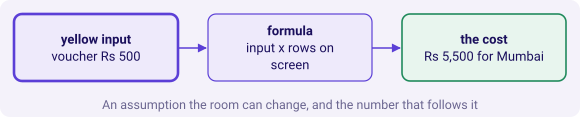

In [8]:
def voucher_cost(voucher, on_screen_mask):
    """The cost formula: the yellow input times the rows a director can see."""
    return voucher * int(sum(on_screen_mask))


for v in [500, 750]:
    print(f"voucher {kit.rupees(v)}: Mumbai {kit.rupees(voucher_cost(v, visible))}, the whole list {kit.rupees(voucher_cost(v, [True] * 50))}")
kit.flow(["yellow input\nvoucher Rs 500", "formula\ninput x rows on screen", "the cost\nRs 5,500 for Mumbai"],
         kinds=["known", "plain", "good"], title="An assumption the room can change, and the number that follows it")
kit.check("the cost follows the input", voucher_cost(750, visible) == 1.5 * voucher_cost(500, visible))
kit.check("the cost follows the filter", voucher_cost(500, visible) == 500 * 11)

**What happened.** The answer is b: Rs 500 times the eleven on screen. The director changes B1 to Rs 750
and the cost becomes Rs 8,250 in front of the room; the list's figures never change, because the
assumption sits beside them and never over them. That is the chief of staff's condition met: the sheet
recalculates, and the source is untouched.

## 5. Which checks does the Checks tab run, and what does its release hold?

The Checks tab turns every trap of the day into a line that reads PASS or HOLD, and one release sentence
reads all of them. Each check compares a number on the sheet with one that comes from somewhere else:

| Check | It compares | It catches |
|---|---|---|
| The tree ties | The tree's two quarters against the warehouse's | A pivot adding payment rows |
| The list's source ties | The customer table's orders and revenue against the warehouse's | A list built on an export that is short |
| The lookup is honest | The lookup's answer for an id known to be missing | An approximate match |
| The foot follows the filter | SUBTOTAL(103) against the rows the foot adds | SUM under a filter |
| No typed-over formula | ISFORMULA on every cell outside the yellow inputs | A director's figure typed over a formula |

The cell below runs the checks in two passes. The first runs the three that read Kalpa's tree, lookup
and foot. The second shows the release deciding, on **invented** inputs: five invented records that fall
short of an invented control total, and a two-cell sheet with one figure typed over its formula.
Chapter 3's your-turn cell runs the source comparison on the real customer table, and that answer is
yours.

**Predict before you run.** In the second pass the invented list's source is short, and the typed-over
sheet is clean. The release: a) ships everything, since four of five checks pass; b) holds the list and
ships the rest; c) holds everything; d) cannot decide.

Check on Kalpa's workbook,Result
the tree ties,PASS
the lookup is honest,PASS
the foot follows the filter,PASS


Inputs,Checks passing,The release
Kalpa's three checks and the invented short source,4 of 5,Hold the protect list; ship the rest.
Kalpa's three checks and a figure typed over B3,4 of 5,Hold the whole workbook until the typed figure is traced.


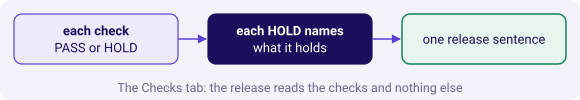

In [9]:
import openpyxl

once = raw.drop_duplicates("order_id")
wq = {r["quarter"]: r["revenue"] for r in warehouse("SELECT quarter, sum(amount) AS revenue FROM orders GROUP BY quarter")}


def find(member):
    hit = table.loc[table["customer_id"] == member, "revenue"]
    return int(hit.iloc[0]) if len(hit) else "not in the table"


kalpa = {"the tree ties": all(int(once.loc[once["quarter"] == q, "order_amount"].sum()) == wq[q] for q in ["Q1", "Q2"]),
         "the lookup is honest": isinstance(find("C-0195"), str),
         "the foot follows the filter": foot(rev, mumbai_filter, no, "SUBTOTAL(109)") == on_screen}
kit.table(["Check on Kalpa's workbook", "Result"], [(k, "PASS" if ok else "HOLD") for k, ok in kalpa.items()],
          caption="First pass: the three checks that read the tree, the lookup and the foot")


def typed_over(sheet, cells):
    """ISFORMULA, cell by cell: the cells outside the yellow inputs that hold a typed figure."""
    return [c for c in cells if not str(sheet[c].value).startswith("=")]


def release(checks):
    holds = {"the list's source ties": "protect list", "the lookup is honest": "protect list",
             "the foot follows the filter": "protect list", "the tree ties": "tree and card",
             "no typed-over formula": "whole workbook"}
    held = sorted({holds[k] for k, ok in checks.items() if not ok})
    if "whole workbook" in held:
        return "Hold the whole workbook until the typed figure is traced."
    return "Ship everything." if not held else f"Hold the {' and the '.join(held)}; ship the rest."


invented_table = [("X-01", 3000), ("X-02", 2500), ("X-03", 2200), ("X-04", 1800), ("X-05", 1500)]   # invented records
invented_control = 12200                                                                           # invented control total
clean_sheet = openpyxl.Workbook().active
clean_sheet["B2"], clean_sheet["B3"] = '=SUMIFS(F:F, C:C, "Retail-Plus", I:I, "Q1")', '=SUMIFS(F:F, C:C, "Retail-Plus", I:I, "Q2")'
edited_sheet = openpyxl.Workbook().active
edited_sheet["B2"], edited_sheet["B3"] = '=SUMIFS(F:F, C:C, "Retail-Plus", I:I, "Q1")', 500000   # a figure typed over B3's formula

second = dict(kalpa, **{"the list's source ties": sum(r for _, r in invented_table) == invented_control,
                        "no typed-over formula": not typed_over(clean_sheet, ["B2", "B3"])})
third = dict(kalpa, **{"the list's source ties": True, "no typed-over formula": not typed_over(edited_sheet, ["B2", "B3"])})
kit.table(["Inputs", "Checks passing", "The release"],
          [("Kalpa's three checks and the invented short source", f"{sum(second.values())} of 5", release(second)),
           ("Kalpa's three checks and a figure typed over B3", f"{sum(third.values())} of 5", release(third))],
          caption="Second pass: the release reads every check, on invented inputs")
kit.flow(["each check\nPASS or HOLD", "each HOLD names\nwhat it holds", "one release sentence"],
         kinds=["plain", "lit", "good"], title="The Checks tab: the release reads the checks and nothing else")
kit.check("Kalpa's tree, lookup and foot checks all pass", all(kalpa.values()))
kit.check("a short source holds the list and nothing else", release(second) == "Hold the protect list; ship the rest.")
kit.check("a typed-over formula holds the whole workbook", typed_over(edited_sheet, ["B2", "B3"]) == ["B3"])

**What happened.** The answer is b. Kalpa's tree, lookup and foot pass. The invented source falls
Rs 1,200 short of its control total, so the list check reads HOLD and the release says: "Hold the
protect list; ship the rest." A figure typed over a formula holds the whole workbook, because nobody can
say which other numbers it has moved. A formula recalculating is never the same as the number being
right, which is why the release reads the checks and nothing else, and why the note that goes with a
HOLD names what does not tie and asks for the export to be rerun.

> **Kavya's review.** "Give the room a sheet it can change and cannot break silently: inputs in yellow,
> every other cell a formula, SUBTOTAL at every foot, and a Checks tab whose release holds whatever does
> not tie. A director who filters, sorts or asks a what-if should see a number move, and never a number
> lie."

### In the interview: how would you answer these three questions aloud?

**[S] A stakeholder wants to poke the numbers themselves. What do you give them, and what do you never
give them?** A workbook on a reconciled export, with the inputs they may change in yellow, a lookup that
says "not in the table", a foot that follows the filter and a Checks tab that holds what does not tie. I
never give them the source to edit, a lookup that can answer with somebody else's row, or a number
without its period and base.

**[F] You filter a list and its total does not move. What is the foot doing?** Adding hidden rows: it is
a SUM. SUBTOTAL(109) adds only what is on screen, and SUBTOTAL(103) beside it counts those rows. Filtered
to Mumbai, the protect list's SUM said Rs 7,14,890 and SUBTOTAL(109) said Rs 1,56,790 for eleven members.

**[D] Two directors change assumptions in the room and the sheet recalculates differently for each.
What did you get right, and what do you fix?** Right: the assumptions are inputs and every number
recomputes from one source, so both answers are honest for their assumptions. Fix: each answer prints its
assumption and its scope beside the number, so down 1.6 percent for all segments and down 17.3 percent
without Business are never compared as one figure, and the scenario never replaces the actual.

### Depth: can a protected sheet still let a director filter?

Excel's sheet protection has options that allow filtering and sorting on a protected sheet, so a team
can lock the formulas and leave the yellow inputs unlocked. It narrows what a director can break and
does not replace the checks: a locked sheet still shows a SUM under a filter, and it cannot tell anyone
that the export under it is short. Protection limits what a director can change; the Checks tab says
whether the numbers can be trusted.

## What did this chapter answer, one question at a time?

1. A director filters, sorts, types over cells, changes inputs and pastes new exports; three of the five change a number's meaning with no error.
2. Option c: yellow inputs, every other cell a formula, and a Checks tab; locking or a PDF fails the brief.
3. Filtered to Mumbai, SUM at the foot still reads Rs 7,14,890 while the eleven on screen spent Rs 1,56,790.
4. SUBTOTAL(109) reads Rs 1,56,790 and SUBTOTAL(103) counts 11 of 50; SUMIFS on the city agrees.
5. An assumption goes in a yellow input that formulas read: a Rs 500 voucher costs Rs 5,500 for Mumbai's eleven.
6. Five checks, each comparing the sheet with something outside it, and a release that holds what a failing check names.

The afternoon's escalated case builds all three deliverables and this Checks tab alone, from the two
exports.

In [10]:
kit.check_summary()